In [1]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import fractional_matrix_power
import sys, os
sys.path.append('../')
from src.spin import *


# Build Hamiltonian

In [3]:
spin_dim = 7/2
Ix = qt.jmat(spin_dim,'x')
Iy = qt.jmat(spin_dim,'y')
Iz = qt.jmat(spin_dim,'z')
Iz2 = Iz*Iz
Ix2 = Ix*Ix

# Electron spin-1/2 operators (2x2 matrices)
Sx = qt.jmat(1/2, 'x')
Sy = qt.jmat(1/2, 'y')
Sz = qt.jmat(1/2, 'z')

In [4]:
np.diff(np.array([7740109, 7723370, 7706110, 7688327, 7670019, 7651177, 7631826]))

array([-16739, -17260, -17783, -18308, -18842, -19351])

In [5]:
H_quad = np.load('../quadrupole modeling/H_quad_fit.npy') # from fit
# H_quad_neutral = np.load('../quadrupole modeling/H_quad_neutral.npy') # from fit

H_nuclear = 5.55 * Iz  # Nuclear Zeeman term
H_electron = 28.8e3 * Sz  # Electron Zeeman term
B_0 = 1.4

A = 97.5
H_hyperfine = A * (qt.tensor(Sx, Ix) + qt.tensor(Sy, Iy) + qt.tensor(Sz, Iz))

H0_ionized = B_0 * H_nuclear
H0_neutral = B_0 * (qt.tensor(H_electron, qt.qeye(8)) + qt.tensor(qt.qeye(2), H_nuclear))

H_ionized = - H0_ionized + qt.Qobj(H_quad)
H_neutral = - H0_neutral - H_hyperfine + qt.tensor(qt.qeye(2), qt.Qobj(H_quad))

# H_ionized = - H0_ionized + 18/22*qt.Qobj(H_quad)
# H_neutral = - H0_neutral - H_hyperfine + 2*qt.tensor(qt.qeye(2), qt.Qobj(H_quad))

H_neutral = qt.Qobj(H_neutral.full())

In [6]:
P_donor = qt.tensor(qt.Qobj(np.array([[1, 0], [0, 1], [0, 0]])), qt.qeye(8))
P_SET = qt.tensor(qt.Qobj(np.array([0, 0, 1])), qt.qeye(8))

H_neutral_full = qt.Qobj(P_donor.full() @ H_neutral.full() @ P_donor.dag().full())
H_ionized_full = qt.Qobj(P_SET.full() @ H_ionized.full() @ P_SET.dag().full())
H_full = H_neutral_full + H_ionized_full

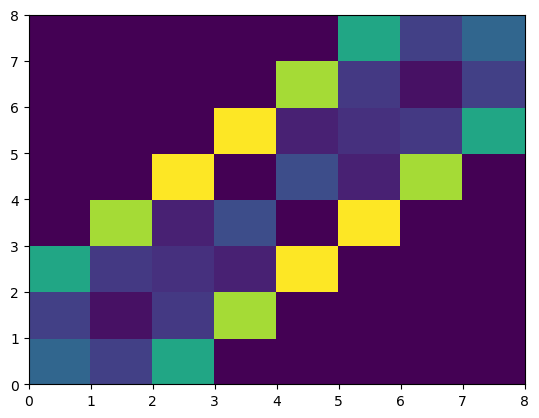

In [7]:
plt.pcolor(np.abs(H_quad))

Text(0.5, 1.0, 'Neutral + Ionized')

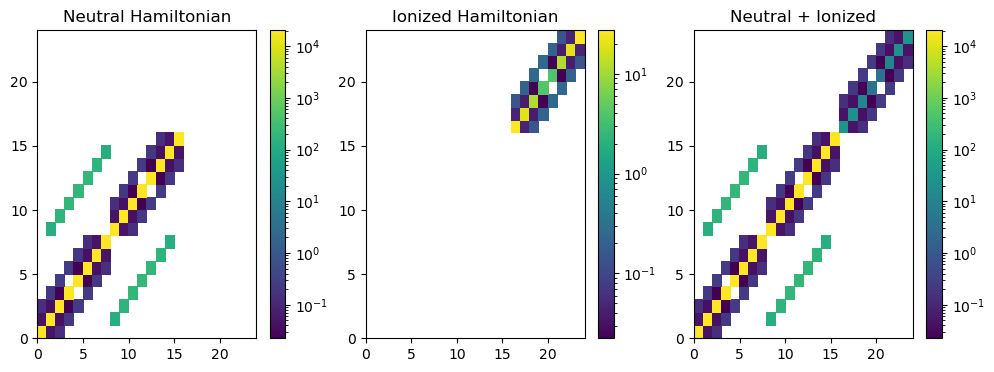

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
pcm1 = ax[0].pcolor(np.abs(H_neutral_full.full()), norm=LogNorm())
pcm2 = ax[1].pcolor(np.abs(H_ionized_full.full()), norm=LogNorm())
pcm3 = ax[2].pcolor(np.abs(H_full.full()), norm=LogNorm())
plt.colorbar(pcm1, ax=ax[0])
plt.colorbar(pcm2, ax=ax[1])
plt.colorbar(pcm3, ax=ax[2])
ax[0].set_title('Neutral Hamiltonian')
ax[1].set_title('Ionized Hamiltonian')
ax[2].set_title('Neutral + Ionized')

In [9]:
(eigenvalues_full, eigenstates_full) = H_full.eigenstates()
eigenstate_full_matrix = np.zeros([24,24], dtype=complex)
for i in range(24):
    idx_argmax = np.argmax(np.abs(eigenstates_full[i].full().flatten())**2)
    eigenstate_full_matrix[idx_argmax] = eigenstates_full[i].full().flatten()

In [10]:
ESR = np.abs(eigenvalues_full[:8] - eigenvalues_full[16:][::-1])
np.diff(ESR)

array([-96.79558914, -97.02769759, -97.26125869, -97.49629521,
       -97.73283028, -97.97088739, -98.21049043])

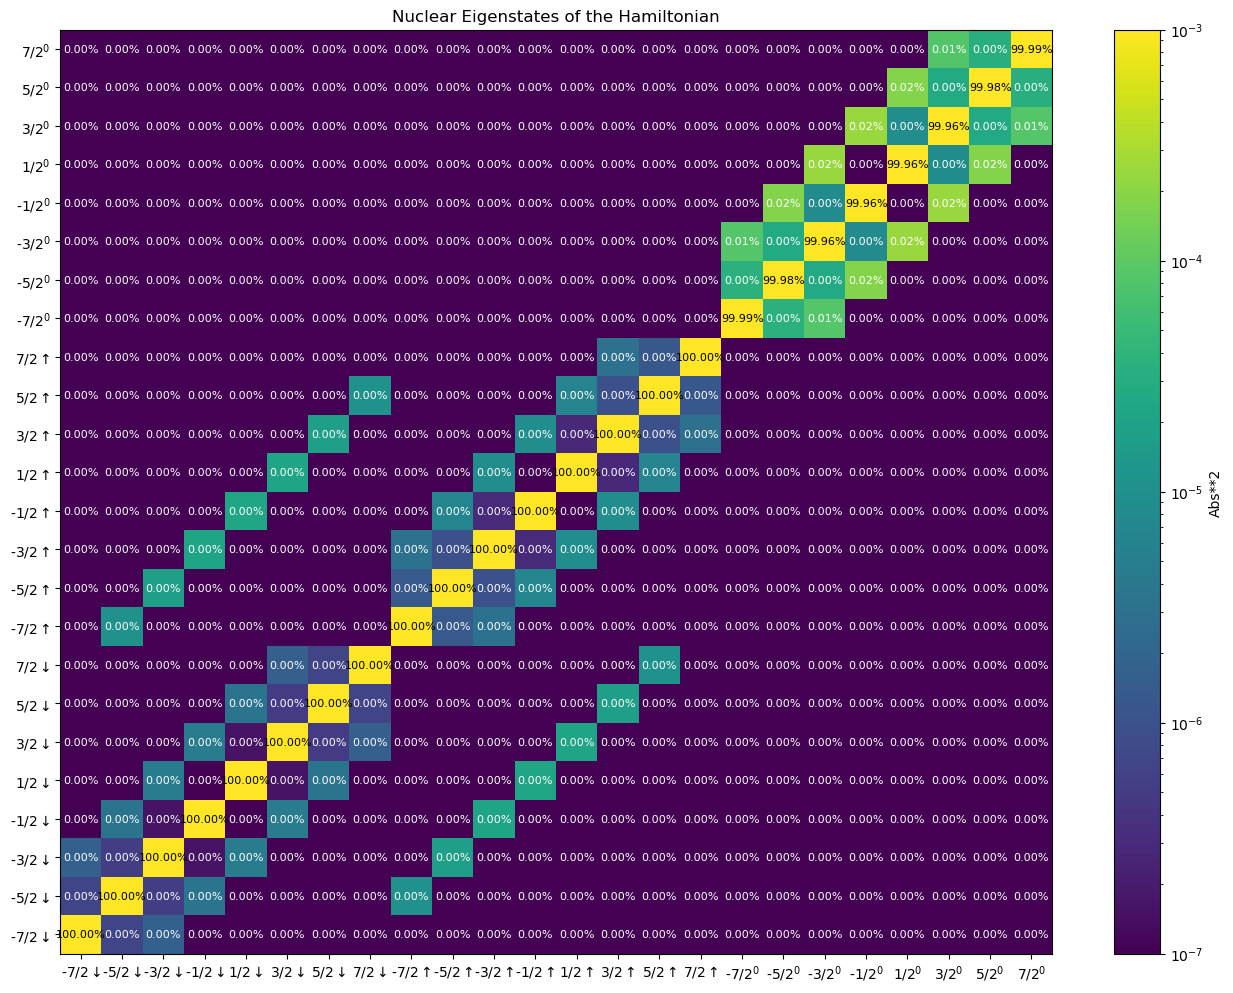

In [12]:
import matplotlib.colors as mcolors
fig, ax = plt.subplots(1,1, figsize=(16,12))
Z = np.abs(eigenstate_full_matrix)**2
X, Y = np.arange(24), np.arange(24)
# Plot with pcolormesh using LogNorm
Z[Z==0]=1e-7

# Convert to percentage
Z_percent = Z * 100  
pcm = plt.pcolormesh(X, Y, Z, norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-3), cmap="viridis")

nucleus_labels = ["-7/2", "-5/2", "-3/2", "-1/2", "1/2", "3/2", "5/2", "7/2"]
electron_labels = [r"$\downarrow$", r"$\uparrow$", r"$^0$"]

ax.set_xticks(np.arange(24))
ax.set_yticks(np.arange(24))
ax.set_xticklabels([nucleus_labels[k%8] + electron_labels[(k//8)] for k in range(24)])
ax.set_yticklabels([nucleus_labels[k%8] + electron_labels[(k//8)] for k in range(24)])

# Annotate with percentages
for i in range(24):
    for j in range(24):
        color = 'black' if i == j else 'white'  # Diagonal elements in black
        ax.text(j, i, f"{Z_percent[i, j]:.2f}%", 
                ha='center', va='center', fontsize=8, color=color)

ax.set_title('Nuclear Eigenstates of the Hamiltonian')

plt.colorbar(label='Abs**2')

In [13]:
nmr_freqs = np.zeros(7)
for i in range(len(nmr_freqs)):
    nmr_freqs[i] = eigenvalues_full[8+i] - eigenvalues_full[8+i+1]

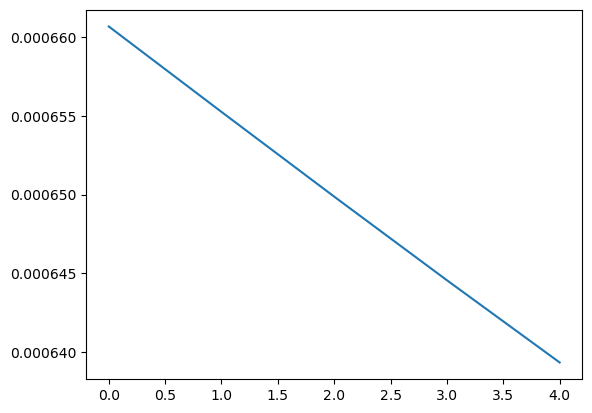

In [14]:
# plt.plot(np.diff(nmr_freqs))
plt.plot(np.diff(np.diff((nmr_freqs))))

# Direct projection

C:\Users\z5380600\AppData\Local\Temp\ipykernel_37248\1365738396.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  transition_matrix_ionize_up[i, j] = np.abs(
C:\Users\z5380600\AppData\Local\Temp\ipykernel_37248\1365738396.py:14: ComplexWarning: Casting complex values to real discards the imaginary part
  transition_matrix_ionize_down[i, j] = np.abs(


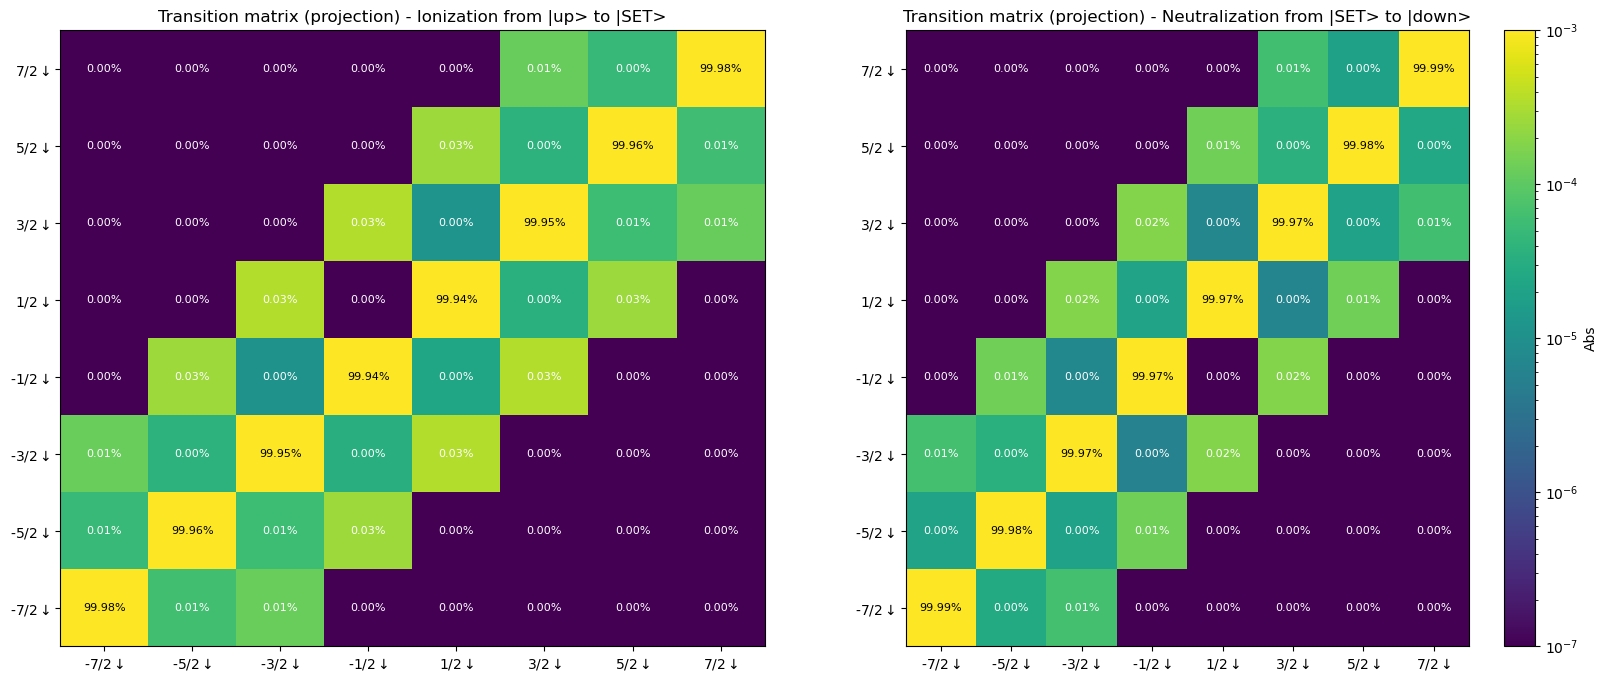

In [15]:
# Compute transition probabilities via direct projection
transition_matrix_ionize_up = np.zeros((8, 8))
transition_matrix_ionize_down = np.zeros((8, 8))
transition_matrix_neutralize_down = np.zeros((8,8))
transition_matrix_neutralize_up = np.zeros((8,8))

for i in range(8):  # Neutral states
    for j in range(8):  # Ionized states

        transition_matrix_ionize_up[i, j] = np.abs(
            np.dot(eigenstate_full_matrix[8+i, 8:16].conj().T, eigenstate_full_matrix[16 + j, 16:])
        )**2 + np.dot(eigenstate_full_matrix[8+i, :8].conj().T, eigenstate_full_matrix[16 + j, 16:])**2

        transition_matrix_ionize_down[i, j] = np.abs(
            np.dot(eigenstate_full_matrix[i, :8].conj().T, eigenstate_full_matrix[16 + j, 16:])
        )**2 + np.dot(eigenstate_full_matrix[i, 8:16].conj().T, eigenstate_full_matrix[16 + j, 16:])**2

transition_matrix_neutralize_up = transition_matrix_ionize_up
transition_matrix_neutralize_down = transition_matrix_ionize_down

fig, ax = plt.subplots(1,2, figsize=(20,8))

Z = np.abs(transition_matrix_ionize_up)
X, Y = np.arange(8), np.arange(8)
# Plot with pcolormesh using LogNorm
Z[Z==0]=1e-7

# Convert to percentage
Z_percent = Z * 100  
pcm = ax[0].pcolormesh(X, Y, Z, norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-3), cmap="viridis")

nucleus_labels = ["-7/2", "-5/2", "-3/2", "-1/2", "1/2", "3/2", "5/2", "7/2"]
electron_labels = [r"$\downarrow$", r"$\uparrow$", r"$^0$"]

ax[0].set_xticks(np.arange(8))
ax[0].set_yticks(np.arange(8))
ax[0].set_xticklabels([nucleus_labels[k%8] + electron_labels[(k//8)] for k in range(8)])
ax[0].set_yticklabels([nucleus_labels[k%8] + electron_labels[(k//8)] for k in range(8)])

# Annotate with percentages
for i in range(8):
    for j in range(8):
        color = 'black' if i == j else 'white'  # Diagonal elements in black
        ax[0].text(j, i, f"{Z_percent[i, j]:.2f}%", 
                ha='center', va='center', fontsize=8, color=color)

ax[0].set_title('Transition matrix (projection) - Ionization from |up> to |SET>')

Z = np.abs(transition_matrix_neutralize_down)
X, Y = np.arange(8), np.arange(8)
# Plot with pcolormesh using LogNorm
Z[Z==0]=1e-7

# Convert to percentage
Z_percent = Z * 100  
pcm = ax[1].pcolormesh(X, Y, Z, norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-3), cmap="viridis")

nucleus_labels = ["-7/2", "-5/2", "-3/2", "-1/2", "1/2", "3/2", "5/2", "7/2"]
electron_labels = [r"$\downarrow$", r"$\uparrow$", r"$^0$"]

ax[1].set_xticks(np.arange(8))
ax[1].set_yticks(np.arange(8))
ax[1].set_xticklabels([nucleus_labels[k%8] + electron_labels[(k//8)] for k in range(8)])
ax[1].set_yticklabels([nucleus_labels[k%8] + electron_labels[(k//8)] for k in range(8)])

# Annotate with percentages
for i in range(8):
    for j in range(8):
        color = 'black' if i == j else 'white'  # Diagonal elements in black
        ax[1].text(j, i, f"{Z_percent[i, j]:.2f}%", 
                ha='center', va='center', fontsize=8, color=color)

ax[1].set_title('Transition matrix (projection) - Neutralization from |SET> to |down>')

plt.colorbar(pcm, ax=ax[1], label='Abs')

In [16]:
np.save(r'sims_data/neutralization_down_matrix.npy', np.abs(transition_matrix_neutralize_down))
np.save(r'sims_data/ionization_up_matrix.npy', np.abs(transition_matrix_ionize_up))

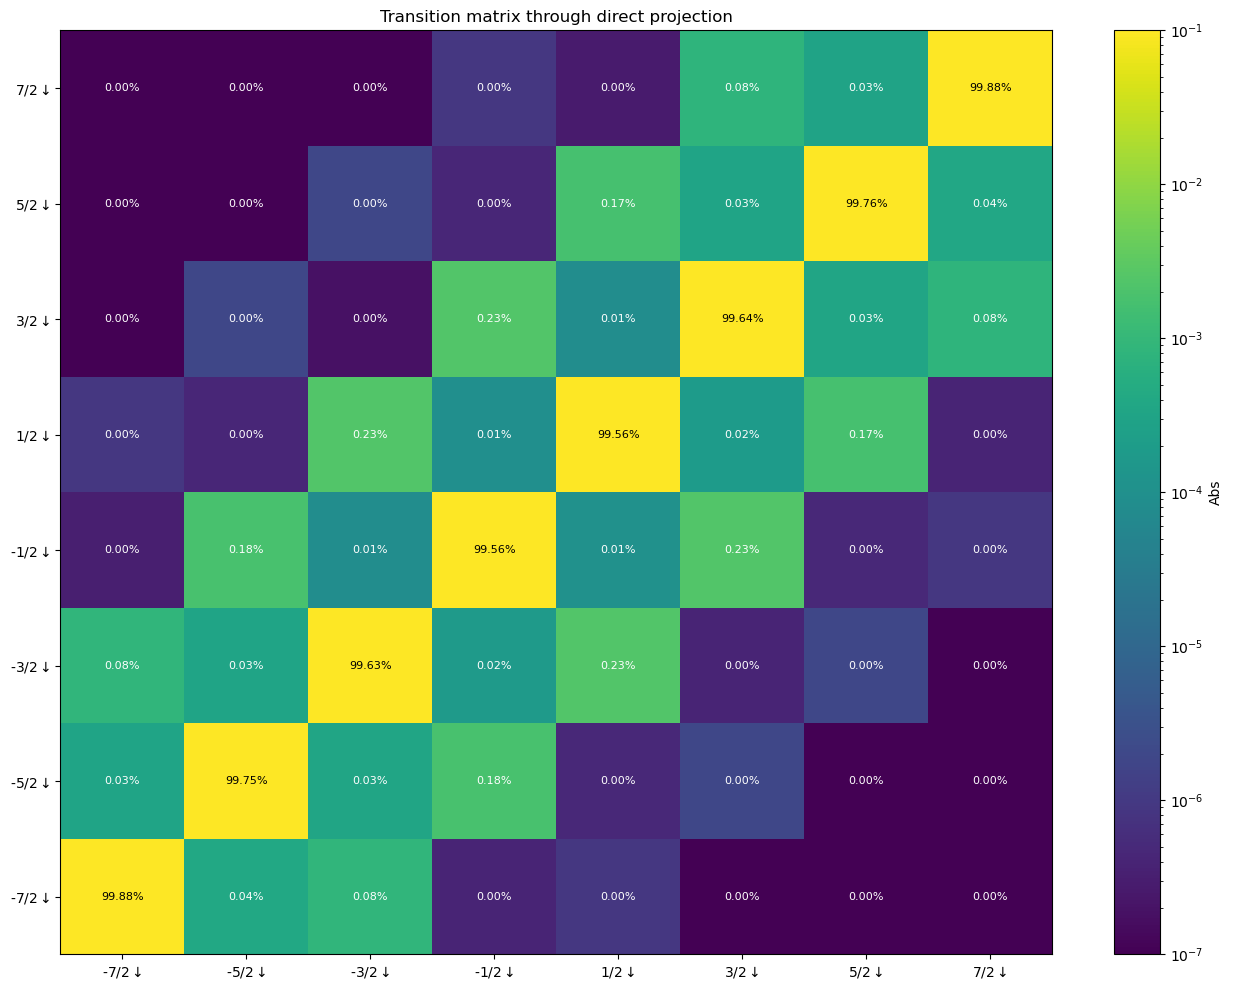

In [17]:
fig, ax = plt.subplots(1,1, figsize=(16,12))
n_tunnel = 4.47
T_est = fractional_matrix_power(np.abs(transition_matrix_neutralize_down) @ np.abs(transition_matrix_ionize_up), n_tunnel)
Z = np.abs(T_est)

X, Y = np.arange(8), np.arange(8)
# Plot with pcolormesh using LogNorm
Z[Z==0]=1e-7

# Convert to percentage
Z_percent = Z * 100  
pcm = ax.pcolormesh(X, Y, Z, norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-1), cmap="viridis")

nucleus_labels = ["-7/2", "-5/2", "-3/2", "-1/2", "1/2", "3/2", "5/2", "7/2"]
electron_labels = [r"$\downarrow$", r"$\uparrow$", r"$^0$"]

ax.set_xticks(np.arange(8))
ax.set_yticks(np.arange(8))
ax.set_xticklabels([nucleus_labels[k%8] + electron_labels[(k//8)] for k in range(8)])
ax.set_yticklabels([nucleus_labels[k%8] + electron_labels[(k//8)] for k in range(8)])

# Annotate with percentages
for i in range(8):
    for j in range(8):
        color = 'black' if i == j else 'white'  # Diagonal elements in black
        ax.text(j, i, f"{Z_percent[i, j]:.2f}%", 
                ha='center', va='center', fontsize=8, color=color)

ax.set_title('Transition matrix through direct projection')

plt.colorbar(pcm, ax=ax, label='Abs')

In [18]:
np.save(r'sims_data/ionization_matrix_proj.npy', T_est)

# Lindblad simulation

We investigate the effect of flip flop relaxation with a Lindblad simulation. The flip flop process is modeled as a collapse operator 

## ionization

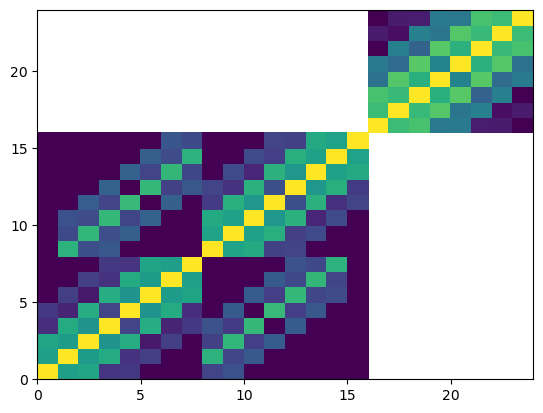

In [19]:
plt.pcolor(np.abs(eigenstate_full_matrix), norm=LogNorm(vmin=1e-7, vmax=1), cmap="viridis")

In [20]:
def find_ionization_ops(rho_0, eigenstate_full_matrix, gamma_out):
    """
    Generate ionization Lindblad operators for a given eigenstate matrix and ionization rate.

    This function calculates the Lindblad operators that describe the ionization process,
    where transitions occur from neutral states to ionized states. The operators are
    constructed based on the eigenstate matrix and the ionization rate.

    Parameters:
    -----------
    eigenstate_full_matrix : numpy.ndarray
        A 2D array where each column represents an eigenstate of the system in the full basis.
    gamma_out : float
        The ionization rate, which determines the strength of the ionization process.

    Returns:
    --------
    ionization_ops : numpy.ndarray
        A 4D array of shape (8, 8, 24, 24) containing the ionization Lindblad operators.
        Each operator corresponds to a specific transition between neutral and ionized states.
    """
    ionization_ops = []
    for i in range(8):
        for j in range(8):
            overlap_top_right = np.abs(np.dot(eigenstate_full_matrix[2*8+i, 2*8:].conj().T, eigenstate_full_matrix[8+j, 8:16]))
            overlap_top_left = np.abs(np.dot(eigenstate_full_matrix[2*8+i, 2*8:].conj().T, eigenstate_full_matrix[8+j, :8]))
            overlap_up = overlap_top_right + overlap_top_left

            overlap_rho_initial = np.abs(np.dot(eigenstate_full_matrix[8+j].conj().T, rho_0 @ eigenstate_full_matrix[8+j]))
            
            # if (overlap_up**2 > 1e-10) & (overlap_rho_initial**2 > 1e-10):
            op = overlap_up * np.sqrt(gamma_out) * eigenstate_full_matrix[2*8+i].reshape(-1, 1) @ eigenstate_full_matrix[8+j].reshape(-1, 1).T.conj()
            ionization_ops.append(qt.Qobj(op))
    return ionization_ops


def find_neutralizing_ops(rho_0, eigenstate_full_matrix, gamma_in):
    """
    Generate neutralizing Lindblad operators for a given eigenstate matrix and neutralization rate.

    This function calculates the Lindblad operators that describe the neutralization process,
    where transitions occur from ionized states to neutral states. The operators are
    constructed based on the eigenstate matrix and the neutralization rate.

    Parameters:
    -----------
    eigenstate_full_matrix : numpy.ndarray
        A 2D array where each column represents an eigenstate of the system in the full basis.
    gamma_in : float
        The neutralization rate, which determines the strength of the neutralization process.

    Returns:
    --------
    neutralizing_ops : numpy.ndarray
        A 4D array of shape (8, 8, 24, 24) containing the neutralization Lindblad operators.
        Each operator corresponds to a specific transition between ionized and neutral states.
    """
    neutralizing_ops = []
    for i in range(8):
        for j in range(8):
            overlap_down_right = np.abs(np.dot(eigenstate_full_matrix[8+i, :8].conj(), eigenstate_full_matrix[2*8+j, 2*8:]))
            overlap_down_left = np.abs(np.dot(eigenstate_full_matrix[i, :8].conj(), eigenstate_full_matrix[2*8+j, 2*8:]))
            overlap_down = overlap_down_left + overlap_down_right

            # if (overlap_down**2 > 1e-10) & (overlap_rho_initial**2 > 1e-10):
            op_down = (overlap_down_left) * np.sqrt(gamma_in) * eigenstate_full_matrix[i].reshape(-1, 1) @ eigenstate_full_matrix[2*8+j].reshape(-1, 1).T.conj()
            neutralizing_ops.append(qt.Qobj(op_down))
            
            op_up = (overlap_down_right) * np.sqrt(gamma_in) * eigenstate_full_matrix[8+i].reshape(-1, 1) @ eigenstate_full_matrix[2*8+j].reshape(-1, 1).T.conj()
            neutralizing_ops.append(qt.Qobj(op_up))
            
    return neutralizing_ops

def find_ionization_op(gamma_out):
    """
    Generate ionization Lindblad operators for a given eigenstate matrix and ionization rate.

    This function calculates the Lindblad operators that describe the ionization process,
    where transitions occur from neutral states to ionized states. The operators are
    constructed based on the eigenstate matrix and the ionization rate.

    Parameters:
    -----------
    eigenstate_full_matrix : numpy.ndarray
        A 2D array where each column represents an eigenstate of the system in the full basis.
    gamma_out : float
        The ionization rate, which determines the strength of the ionization process.

    Returns:
    --------
    ionization_ops : numpy.ndarray
        A 4D array of shape (8, 8, 24, 24) containing the ionization Lindblad operators.
        Each operator corresponds to a specific transition between neutral and ionized states.
    """
    ionization_op = np.zeros((24, 24), dtype=complex)

    set_ket = qt.tensor(qt.basis(3, 2), qt.qeye(8))
    up_bra = qt.tensor(qt.basis(3, 1), qt.qeye(8)).dag()
    ionization_op = np.sqrt(gamma_out) * set_ket * up_bra
    
    return ionization_op.full()

def find_neutralizing_op(gamma_in):
    """
    Generate neutralizing Lindblad operators for a given eigenstate matrix and neutralization rate.

    This function calculates the Lindblad operators that describe the neutralization process,
    where transitions occur from ionized states to neutral states. The operators are
    constructed based on the eigenstate matrix and the neutralization rate.

    Parameters:
    -----------
    eigenstate_full_matrix : numpy.ndarray
        A 2D array where each column represents an eigenstate of the system in the full basis.
    gamma_in : float
        The neutralization rate, which determines the strength of the neutralization process.

    Returns:
    --------
    neutralizing_ops : numpy.ndarray
        A 4D array of shape (8, 8, 24, 24) containing the neutralization Lindblad operators.
        Each operator corresponds to a specific transition between ionized and neutral states.
    """
    neutralizing_op = np.zeros((24, 24), dtype=complex)
    set_bra = qt.tensor(qt.basis(3, 2), qt.qeye(8)).dag()
    down_ket = qt.tensor(qt.basis(3, 0), qt.qeye(8))
    neutralizing_op = np.sqrt(gamma_in) * down_ket * set_bra

    return neutralizing_op.full()

def find_esr_op(gamma_in):
    """
    Generate the ESR (Electron Spin Resonance) Lindblad operator.

    This function calculates the Lindblad operator that describes the ESR process,
    where transitions occur from the spin-down state to the spin-up state. The operator
    is constructed based on the given transition rate.

    Parameters:
    -----------
    gamma_in : float
        The ESR transition rate, which determines the strength of the spin-flip process.

    Returns:
    --------
    esr_op : numpy.ndarray
        A 2D array of shape (24, 24) representing the ESR Lindblad operator.
    """
    esr_op = np.zeros((24, 24), dtype=complex)
    down_bra = qt.tensor(qt.basis(3, 0), qt.qeye(8)).dag()
    up_ket = qt.tensor(qt.basis(3, 1), qt.qeye(8))
    esr_op = np.sqrt(gamma_in) * up_ket * down_bra

    return esr_op.full()

def find_neutralizing_op_spin_up(gamma_in_up):
    """
    Generate neutralizing Lindblad operators for a given eigenstate matrix and neutralization rate.

    This function calculates the Lindblad operators that describe the neutralization process,
    where transitions occur from ionized states to neutral states. The operators are
    constructed based on the eigenstate matrix and the neutralization rate.

    Parameters:
    -----------
    eigenstate_full_matrix : numpy.ndarray
        A 2D array where each column represents an eigenstate of the system in the full basis.
    gamma_in : float
        The neutralization rate, which determines the strength of the neutralization process.

    Returns:
    --------
    neutralizing_ops : numpy.ndarray
        A 4D array of shape (8, 8, 24, 24) containing the neutralization Lindblad operators.
        Each operator corresponds to a specific transition between ionized and neutral states.
    """
    neutralizing_op = np.zeros((24, 24), dtype=complex)
    set_bra = qt.tensor(qt.basis(3, 2), qt.qeye(8)).dag()
    up_ket = qt.tensor(qt.basis(3, 0), qt.qeye(8))
    neutralizing_op = np.sqrt(gamma_in_up) * up_ket * set_bra

    return neutralizing_op.full()

def find_neutralizing_ops_with_error(eigenstate_full_matrix, gamma_in, p_incorrect=0.03):
    """
    Generate neutralizing Lindblad operators with a probability of incorrect transitions (spin up loading).

    Parameters:
    -----------
    eigenstate_full_matrix : numpy.ndarray
        A 2D array where each column represents an eigenstate of the system in the full basis.
    gamma_in : float
        The neutralization rate, which determines the strength of the neutralization process.
    p_incorrect : float
        The probability of an incorrect transition during neutralization.

    Returns:
    --------
    neutralizing_ops : numpy.ndarray
        A 4D array of shape (8, 8, 24, 24) containing the neutralization Lindblad operators.
    """
    neutralizing_ops = np.zeros((8, 8, 24, 24), dtype=complex)
    for i in range(8):  # Neutral states
        for j in range(8):  # Ionized states
            # Correct transition (SET to spin-down)
            overlap_top_left = np.abs(np.dot(eigenstate_full_matrix[i, :8].conj().T, eigenstate_full_matrix[2*8+j, 2*8:]))
            overlap_down_left = np.abs(np.dot(eigenstate_full_matrix[i, 8:2*8].conj().T, eigenstate_full_matrix[2*8+j, 2*8:]))
            
            overlap_down = overlap_top_left + overlap_down_left
            op_down = (1 - p_incorrect) * overlap_down * np.sqrt(gamma_in) * eigenstate_full_matrix[i].reshape(-1, 1) @ eigenstate_full_matrix[2*8+j].reshape(-1, 1).T.conj()

            # Incorrect transition (SET to spin-up)
            overlap_top_right = np.abs(np.dot(eigenstate_full_matrix[2*8+i, 2*8:].conj().T, eigenstate_full_matrix[8+j, 8:16]))
            overlap_down_right = np.abs(np.dot(eigenstate_full_matrix[2*8+i, 2*8:].conj().T, eigenstate_full_matrix[8+j, :8]))

            overlap_up = overlap_top_right + overlap_down_right
            op_up = p_incorrect * overlap_up * np.sqrt(gamma_in) * eigenstate_full_matrix[2*8+i].reshape(-1, 1) @ eigenstate_full_matrix[8+j].reshape(-1, 1).T.conj()

            # Combine correct and incorrect transitions
            neutralizing_ops[i, j] = op_down + op_up
    return neutralizing_ops

def find_flip_flop_op(gamma_flip_flop):
    """
    Generate Lindblad operators for flip-flop relaxation processes.

    Parameters:
    -----------
    eigenstate_full_matrix : numpy.ndarray
        A 2D array where each column represents an eigenstate of the system in the full basis.
    gamma_flip_flop : float
        The rate of the flip-flop relaxation process.

    Returns:
    --------
    flip_flop_ops : list of Qobj
        A list of Lindblad operators describing the flip-flop relaxation processes.
    """
    flip_flop_op = np.zeros((8, 24, 24), dtype=complex)
    up_bra = qt.tensor(qt.basis(3, 1), qt.Qobj(np.eye(8, 8, -1))).dag()
    down_ket = qt.tensor(qt.basis(3, 0), qt.Qobj(np.eye(8, 8, 0)))
    flip_flop_op = np.sqrt(gamma_flip_flop) * down_ket * up_bra

    return flip_flop_op.full()

def find_ionized_measurement_op(gamma_meas):
    """
    Generate the ionized measurement operator.

    This function constructs the measurement operator for the ionized state, which is used to
    determine the state of the system after a measurement process.

    Returns:
    --------
    ionized_measurement_op : numpy.ndarray
        A 2D array representing the ionized measurement operator.
    """
    ionized_measurement_ops = np.zeros((8, 24, 24), dtype=complex)
    for i in range(8):
        ionized_measurement_ops[i] = np.sqrt(gamma_meas) * eigenstate_full_matrix[2*8+i].reshape(-1, 1) @ eigenstate_full_matrix[2*8+i].reshape(-1, 1).T.conj()

    return ionized_measurement_ops

In [22]:
# initial state: neutral state |7/2, up> (first column of eigenstate_full_matrix)
rho_0 = qt.ket2dm(qt.Qobj(eigenstate_full_matrix[8+0]))

gamma_out = 1/1e-6
gamma_in = 1/1e-6
gamma_ff = 1/1e-6
# Generate the Lindblad operators for ionization and neutralization processes

esr_op = find_esr_op(gamma_in)
ionization_op = find_ionization_op(gamma_out)
ionization_ops = find_ionization_ops(rho_0.full(), eigenstate_full_matrix, gamma_in)
neutralizing_ops = find_neutralizing_ops(rho_0.full(), eigenstate_full_matrix, gamma_in)
ff_ops = find_flip_flop_op(gamma_ff)
ion_meas_ops = find_ionized_measurement_op(gamma_out)

In [23]:
neutralizing_op = find_neutralizing_op(gamma_in)

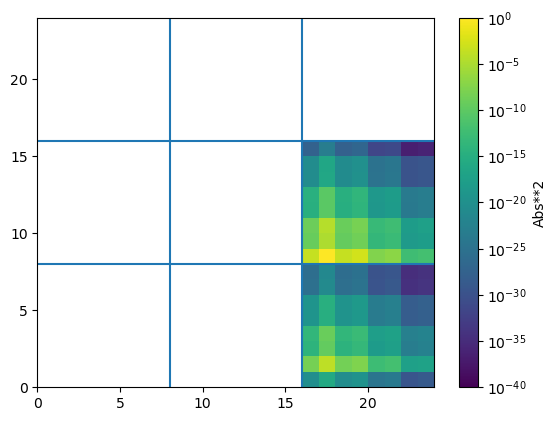

In [25]:

# example of an ionization operator, that ionizes from |5/2, up> to |5/2, SET>
plt.pcolormesh(np.abs(neutralizing_ops[3].full())**2, norm=mcolors.LogNorm(vmin=1e-40, vmax=1), cmap="viridis")
plt.colorbar(label='Abs**2')
plt.axvline(8)
plt.axhline(8)
plt.axvline(16)
plt.axhline(16)

In [26]:
rho_72 = eigenstate_full_matrix[2*8+0].reshape(-1, 1) @ eigenstate_full_matrix[2*8+0].reshape(-1, 1).T.conj()

In [27]:
# initial state: neutral state |7/2, up> (first column of eigenstate_full_matrix)
rho_0 = qt.ket2dm(qt.Qobj(eigenstate_full_matrix[8+0]))

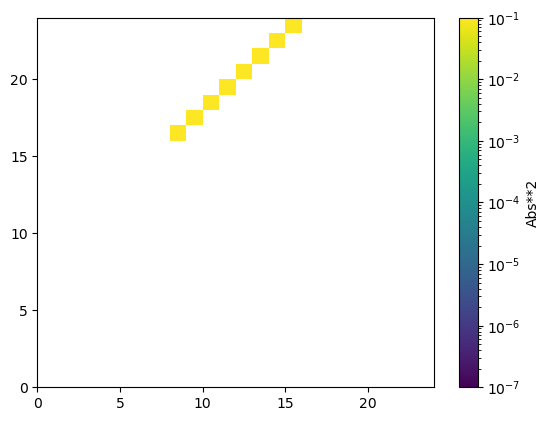

In [30]:
# example of an ionization operator, that ionizes from |5/2, up> to |5/2, SET>
plt.pcolormesh(np.abs(ionization_op)**2, norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-1), cmap="viridis")
plt.colorbar(label='Abs**2')

In [31]:
t_list = np.linspace(0, 1e-3, 10)

# Generalize ionization shock

In [32]:
# def compute_ionization_shock(rho_0, eigenstate_full_matrix, H_full, gamma_out, gamma_in, gamma_ff, t_list):
def compute_ionization_shock(rho_0, eigenstate_full_matrix, H_full, gamma_out, gamma_in, gamma_ff, t_list):
    """
    Compute the ionization shock for a given initial neutral eigenstate.

    Parameters:
    -----------
    initial_state_index : int
        The index of the initial neutral eigenstate (0-7 for neutral states).
    eigenstate_full_matrix : numpy.ndarray
        A 2D array where each column represents an eigenstate of the system in the full basis.
    H_full : Qobj
        The full Hamiltonian of the system.
    gamma_out : float
        The ionization rate.
    gamma_in : float
        The neutralization rate.
    t_list : numpy.ndarray
        The time points for the evolution.

    Returns:
    --------
    result : dict
        A dictionary containing the final states after ionization, measurement, and neutralization.
    """

    # Step 2: Generate ionization operators
    ionization_ops = find_ionization_ops(rho_0.full(), eigenstate_full_matrix, gamma_out)
    print(len(ionization_ops))
    flip_flop_op = find_flip_flop_op(gamma_ff)
    
    jump_ops_ionization = ionization_ops
    jump_ops_flip_flop = [qt.Qobj(flip_flop_op)]
    options = qt.Options(store_final_state=True, nsteps=1000, atol=1e-8, rtol=1e-6)
    result_ionization = qt.mesolve(H_full, rho_0, t_list, c_ops=ionization_ops, e_ops=[], args={}, options=options)

    ionized_state = result_ionization.states[-1]



    # Step 5: Generate neutralization operators
    neutralizing_ops = find_neutralizing_ops(ionized_state.full(), eigenstate_full_matrix, gamma_in)
    print(len(neutralizing_ops))
    # jump_ops_neutralization = [qt.Qobj(neutralizing_ops[i, j]) for i in range(8) for j in range(8)]
    # neutralizing_op = find_neutralizing_op(eigenstate_full_matrix, gamma_in)

    # Step 6: Perform neutralization
    
    result_neutralization = qt.mesolve(H_full, ionized_state, t_list, c_ops=neutralizing_ops, options=options)
    neutralized_state = result_neutralization.states[-1]


    # Return results
    return {
        "ionized_state": ionized_state,
        "neutralized_state": neutralized_state,
    }

# def compute_ionization_shock(rho_0, eigenstate_full_matrix, H_full, gamma_out, gamma_in, gamma_ff, t_list):
def compute_ionization_shock_simple(rho_0, H_full, gamma_out, gamma_in, gamma_ff, t_list):
    """
    Compute the ionization shock for a given initial state using simplified operators.

    Parameters:
    -----------
    rho_0 : Qobj
        The initial density matrix of the system.
    H_full : Qobj
        The full Hamiltonian of the system.
    gamma_out : float
        The ionization rate.
    gamma_in : float
        The neutralization rate.
    gamma_ff : float
        The flip-flop rate.
    t_list : numpy.ndarray
        The time points for the evolution.

    Returns:
    --------
    result : dict
        A dictionary containing the final states after ionization, measurement, and neutralization.
    """

    # Generate ionization, neutralizing, and flip-flop operators
    ionization_op = find_ionization_op(gamma_out)
    neutralizing_op = find_neutralizing_op(gamma_in)
    flip_flop_op = find_flip_flop_op(gamma_ff)

    # jump_ops_esr = [qt.Qobj(esr_op), qt.Qobj(flip_flop_op)]
    # result_esr = qt.mesolve(H_full, rho_0, t_list, c_ops=jump_ops_esr, e_ops=[], args={}, options=None)
    # spin_up_state = result_esr.states[-1]
    
    # Perform ionization with ionization and flip-flop operators
    jump_ops_ionization = [qt.Qobj(ionization_op), qt.Qobj(flip_flop_op)]
    result_ionization = qt.mesolve(H_full, rho_0, t_list, c_ops=[], e_ops=[], args={}, options=None)
    ionized_state = result_ionization.states[-1]

    # Perform measurement on the ionized state
    # measure_ionized_op = find_ionized_measurement_op(gamma_out)
    # jump_ops_measure = [qt.Qobj(measure_ionized_op[i]) for i in range(8)]
    # result_measured = qt.mesolve(H_full, ionized_state, t_list, c_ops=jump_ops_measure)
    # measured_state = result_measured.states[-1]

    # Perform neutralization with neutralizing and flip-flop operators
    result_neutralization = qt.mesolve(H_full, ionized_state, t_list, c_ops=[qt.Qobj(neutralizing_op), qt.Qobj(flip_flop_op)])
    neutralized_state = result_neutralization.states[-1]

    # Return results
    return {
        # "spin_up_state" : spin_up_state,
        "ionized_state": ionized_state,
        # "measured_state": measured_state,
        "neutralized_state": neutralized_state,
    }


# def compute_ionization_shock(rho_0, eigenstate_full_matrix, H_full, gamma_out, gamma_in, gamma_ff, t_list):
def compute_ionization_shock_simple_with_error(rho_0, H_full, gamma_out, gamma_in, gamma_ff, t_list):
    """
    Compute the ionization shock for a given initial state using simplified operators.

    Parameters:
    -----------
    rho_0 : Qobj
        The initial density matrix of the system.
    H_full : Qobj
        The full Hamiltonian of the system.
    gamma_out : float
        The ionization rate.
    gamma_in : float
        The neutralization rate.
    gamma_ff : float
        The flip-flop rate.
    t_list : numpy.ndarray
        The time points for the evolution.

    Returns:
    --------
    result : dict
        A dictionary containing the final states after ionization, measurement, and neutralization.
    """

    # Generate ionization, neutralizing, and flip-flop operators
    ionization_op = find_ionization_op(gamma_out)
    neutralizing_op = find_neutralizing_op(gamma_in)
    flip_flop_op = find_flip_flop_op(gamma_ff)
    
    # Perform ionization with ionization and flip-flop operators
    jump_ops_ionization = [qt.Qobj(ionization_op), qt.Qobj(flip_flop_op)]
    result_ionization = qt.mesolve(H_full, rho_0, t_list, c_ops=jump_ops_ionization, e_ops=[], args={}, options=None)
    ionized_state = result_ionization.states[-1]

    # Perform measurement on the ionized state
    measure_ionized_op = find_ionized_measurement_op(gamma_out)
    jump_ops_measure = [qt.Qobj(measure_ionized_op[i]) for i in range(8)]
    result_measured = qt.mesolve(H_full, ionized_state, t_list, c_ops=jump_ops_measure)
    measured_state = result_measured.states[-1]

    # Perform neutralization with neutralizing and flip-flop operators and spin up loading error
    neutralizing_op_error = find_neutralizing_op_spin_up(gamma_in*0.03)
    result_neutralization = qt.mesolve(H_full, measured_state, t_list, c_ops=[qt.Qobj(neutralizing_op), qt.Qobj(flip_flop_op), qt.Qobj(neutralizing_op_error)])
    neutralized_state = result_neutralization.states[-1]

    # Return results
    return {
        "ionized_state": ionized_state,
        "measured_state": measured_state,
        "neutralized_state": neutralized_state,
    }


# Function to transform a density matrix into the eigenbasis
def transform_to_eigenbasis(rho, transformation_matrix):
    return transformation_matrix.conj() @ rho @ transformation_matrix.T

def compute_ionization_shock_with_error(rho_0, eigenstate_full_matrix, H_full, gamma_out, gamma_in, t_list, p_incorrect=0.05):
    """
    Compute the ionization shock for a given initial neutral eigenstate.

    Parameters:
    -----------
    initial_state_index : int
        The index of the initial neutral eigenstate (0-7 for neutral states).
    eigenstate_full_matrix : numpy.ndarray
        A 2D array where each column represents an eigenstate of the system in the full basis.
    H_full : Qobj
        The full Hamiltonian of the system.
    gamma_out : float
        The ionization rate.
    gamma_in : float
        The neutralization rate.
    t_list : numpy.ndarray
        The time points for the evolution.

    Returns:
    --------
    result : dict
        A dictionary containing the final states after ionization, measurement, and neutralization.
    """

    # Step 2: Generate ionization operators
    ionization_ops = find_ionization_ops_with_error(eigenstate_full_matrix, gamma_out)
    jump_ops_ionization = [qt.Qobj(ionization_ops[i, j]) for i in range(8) for j in range(8)]

    # Step 3: Perform ionization
    result_ionization = qt.mesolve(H_full, rho_0, t_list, c_ops=jump_ops_ionization)
    ionized_state = result_ionization.states[-1]

    # Step 5: Generate neutralization operators
    neutralizing_ops = find_neutralizing_ops_with_error(eigenstate_full_matrix, gamma_in, p_incorrect)
    jump_ops_neutralization = [qt.Qobj(neutralizing_ops[i, j]) for i in range(8) for j in range(8)]

    # Step 6: Perform neutralization
    result_neutralization = qt.mesolve(H_full, ionized_state, t_list, c_ops=jump_ops_neutralization)
    neutralized_state = result_neutralization.states[-1]


    # Return results
    return {
        "ionized_state": ionized_state,
        "neutralized_state": neutralized_state,
    }

In [43]:
# Parameters
initial_state_index = 3  # Example: Neutral state |7/2, up>
gamma_out = 1 / 1e-6
gamma_in = 1 / 1e-6
gamma_ff = gamma_in * 0.00005
t_list = np.linspace(0, 1e-3, 10)

# spin_up_states = np.zeros([8, 24, 24], dtype=complex)
ionized_states = np.zeros((8, 24, 24), dtype=complex)
measured_states = np.zeros((8, 24, 24), dtype=complex)
# spin_up_states_eigenbasis = np.zeros([8, 24, 24], dtype=complex)
ionized_states_eigenbasis = np.zeros((8, 24, 24), dtype=complex)
neutralized_states = np.zeros((8, 24, 24), dtype=complex)
neutralized_states_eigenbasis = np.zeros((8, 24, 24), dtype=complex)
measured_states_eigenbasis = np.zeros((8, 24, 24), dtype=complex)
# Loop over all initial states |i, up> (i = 0 to 7)

for i in range(8):
    # Compute ionization shock for each initial state |i, up>
    rho_0 = qt.ket2dm(qt.Qobj(eigenstate_full_matrix[8+i]))
    result = compute_ionization_shock(rho_0, eigenstate_full_matrix, H_full, gamma_out, gamma_in, gamma_ff, t_list)
    # spin_up_states[i] = result['spin_up_state'].full()
    ionized_states[i] = result["ionized_state"].full()
    # measured_states[i] = result["measured_state"].full()
    neutralized_states[i] = result["neutralized_state"].full()
    # spin_up_states_eigenbasis[i] = transform_to_eigenbasis(result["spin_up_state"].full(), eigenstate_full_matrix)
    ionized_states_eigenbasis[i] = transform_to_eigenbasis(result["ionized_state"].full(), eigenstate_full_matrix)
    neutralized_states_eigenbasis[i] = transform_to_eigenbasis(result["neutralized_state"].full(), eigenstate_full_matrix)
    # measured_states_eigenbasis[i] = transform_to_eigenbasis(result["measured_state"].full(), eigenstate_full_matrix)

64


c:\Users\z5380600\AppData\Local\anaconda3\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


128
64
128
64
128
64
128
64
128
64
128
64
128
64
128


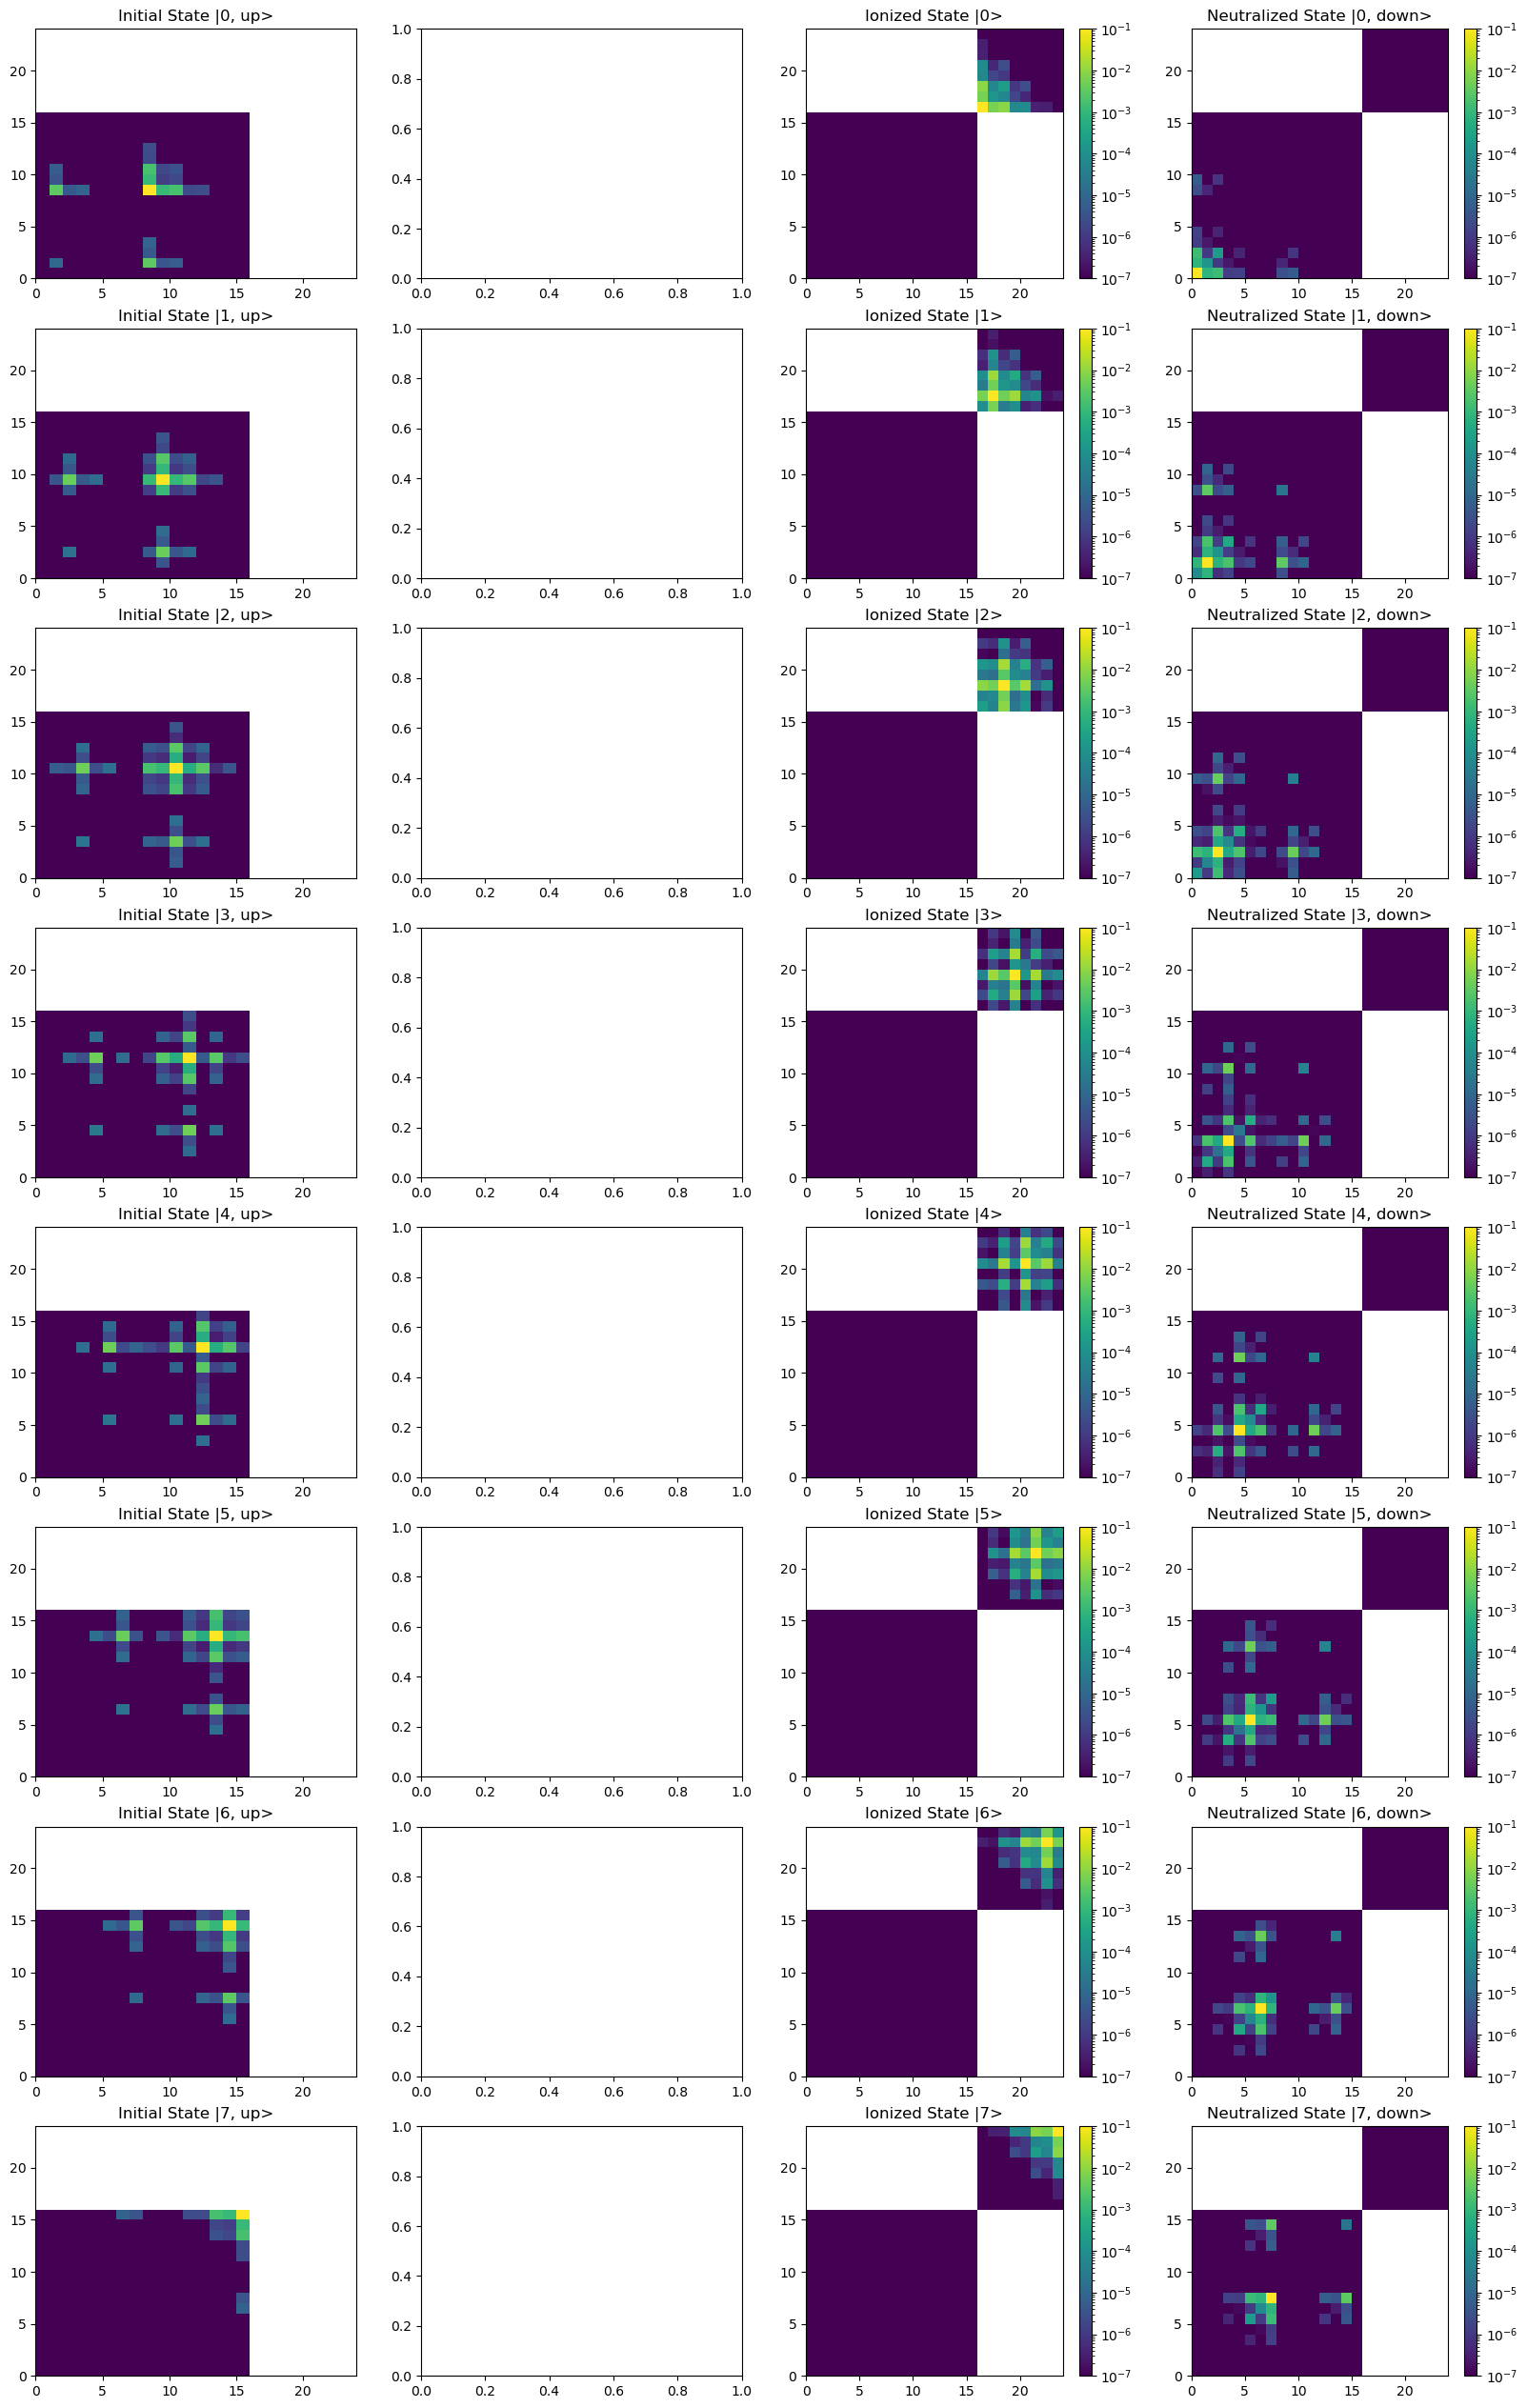

In [44]:
# Plotting the results
fig, ax = plt.subplots(8, 4, figsize=(20, 32))
for i in range(8):
    # Initial state
    rho_0 = qt.ket2dm(qt.Qobj(eigenstate_full_matrix[8+i]))

    ax[i, 0].pcolormesh(np.abs(rho_0.full()), norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-1), cmap="viridis")
    ax[i, 0].set_title(f"Initial State |{i}, up>")
    
    # spin up state
    # pcm1 = ax[i, 1].pcolormesh(np.abs(spin_up_states[i]), norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-1), cmap="viridis")
    # ax[i, 1].set_title(f"Ionized State |{i}>")
    # plt.colorbar(pcm1, ax=ax[i, 1])
    
    # Ionized state
    pcm1 = ax[i, 2].pcolormesh(np.abs(ionized_states[i]), norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-1), cmap="viridis")
    ax[i, 2].set_title(f"Ionized State |{i}>")
    plt.colorbar(pcm1, ax=ax[i, 2])

    # Neutralized state
    pcm3 = ax[i, 3].pcolormesh(np.abs(neutralized_states[i]), norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-1), cmap="viridis")
    ax[i, 3].set_title(f"Neutralized State |{i}, down>")
    plt.colorbar(pcm3, ax=ax[i, 3])


## transform to eigenbasis

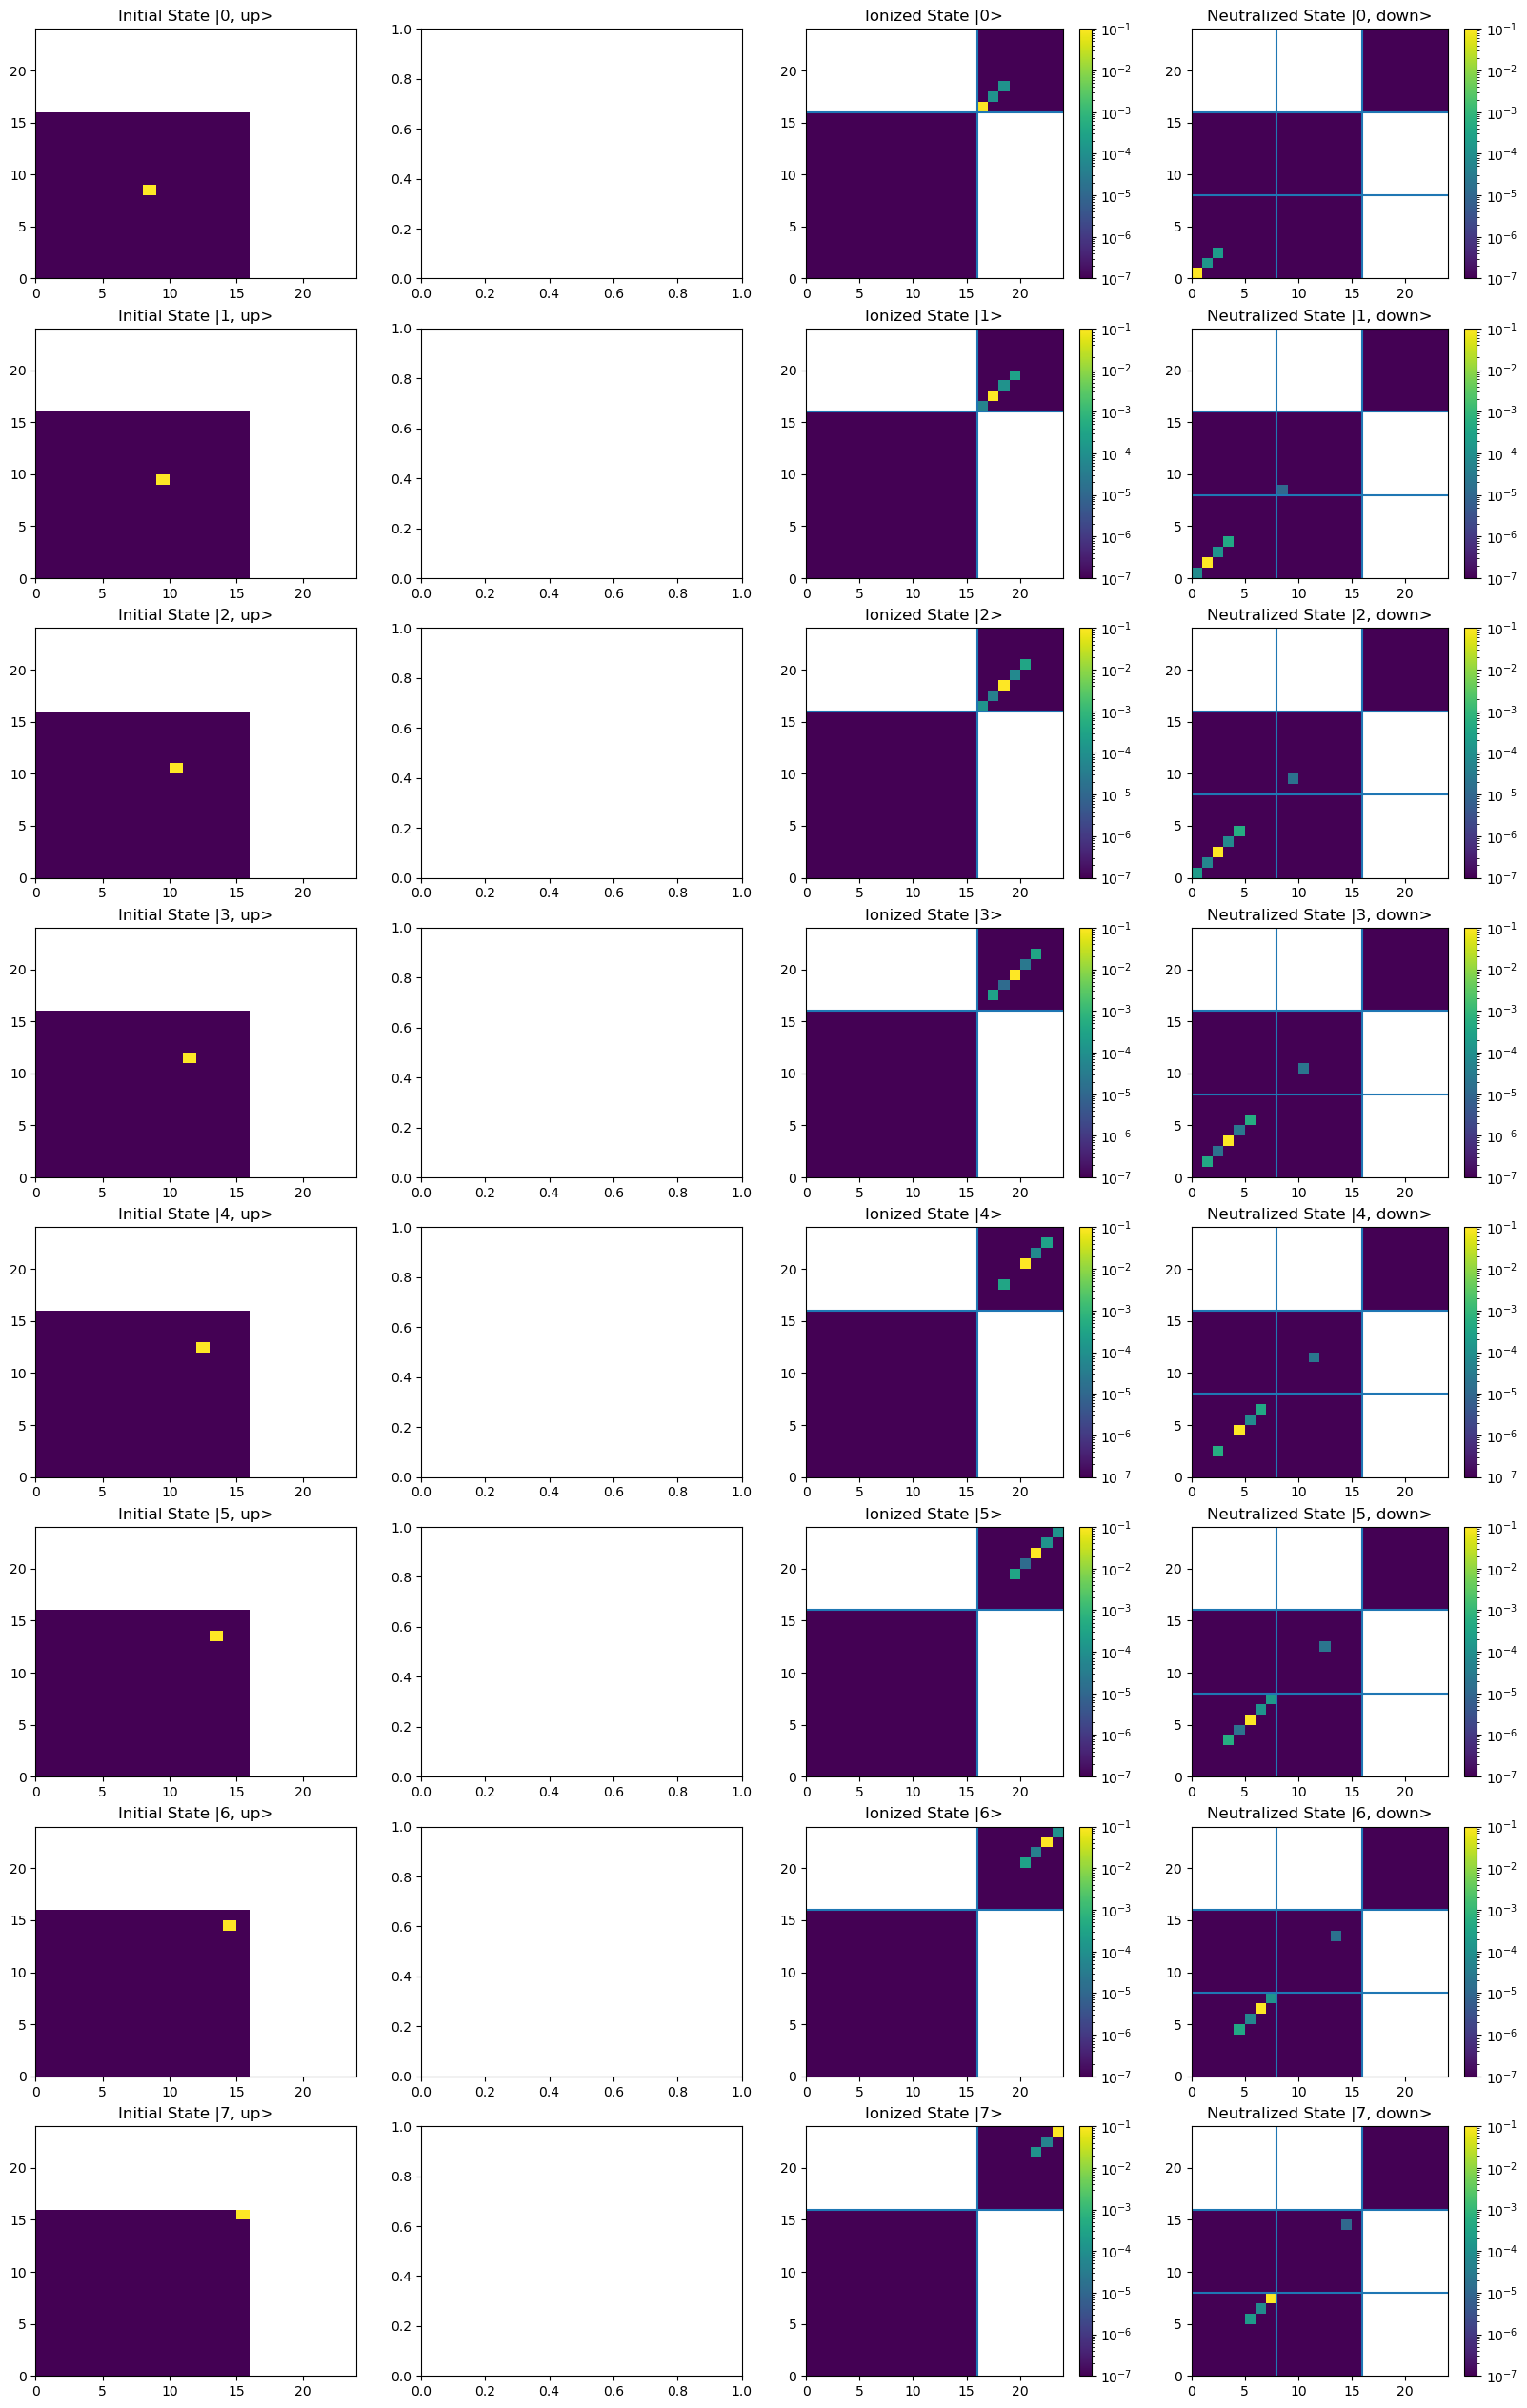

In [45]:
# Plotting the results
fig, ax = plt.subplots(8, 4, figsize=(20, 32))
for i in range(8):
    # Initial state
    rho_0 = qt.ket2dm(qt.Qobj(eigenstate_full_matrix[8+i]))

    ax[i, 0].pcolormesh(np.abs(transform_to_eigenbasis(rho_0.full(), eigenstate_full_matrix)), norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-1), cmap="viridis")
    ax[i, 0].set_title(f"Initial State |{i}, up>")
    
    # spin up state
    # pcm1 = ax[i, 1].pcolormesh(np.abs(spin_up_states_eigenbasis[i]), norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-1), cmap="viridis")
    # ax[i, 1].set_title(f"Ionized State |{i}>")
    # plt.colorbar(pcm1, ax=ax[i, 1])
    
    # Ionized state
    pcm1 = ax[i, 2].pcolormesh(np.abs(ionized_states_eigenbasis[i]), norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-1), cmap="viridis")
    ax[i, 2].set_title(f"Ionized State |{i}>")
    ax[i, 2].axhline(16)
    ax[i, 2].axvline(16)
    plt.colorbar(pcm1, ax=ax[i, 2])

    # Neutralized state
    pcm3 = ax[i, 3].pcolormesh(np.abs(neutralized_states_eigenbasis[i]), norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-1), cmap="viridis")
    ax[i, 3].set_title(f"Neutralized State |{i}, down>")
    ax[i, 3].axhline(16)
    ax[i, 3].axvline(16)
    ax[i, 3].axhline(8)
    ax[i, 3].axvline(8)
    plt.colorbar(pcm3, ax=ax[i, 3])

In [46]:
ionization_matrix = np.zeros((8, 8))
for i in range(8):
    ionization_matrix[i] = np.diag(neutralized_states_eigenbasis[i])[0:8] + np.diag(neutralized_states_eigenbasis[i])[8:16] + np.diag(neutralized_states_eigenbasis[i])[16:]

C:\Users\z5380600\AppData\Local\Temp\ipykernel_37248\495180801.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  ionization_matrix[i] = np.diag(neutralized_states_eigenbasis[i])[0:8] + np.diag(neutralized_states_eigenbasis[i])[8:16] + np.diag(neutralized_states_eigenbasis[i])[16:]


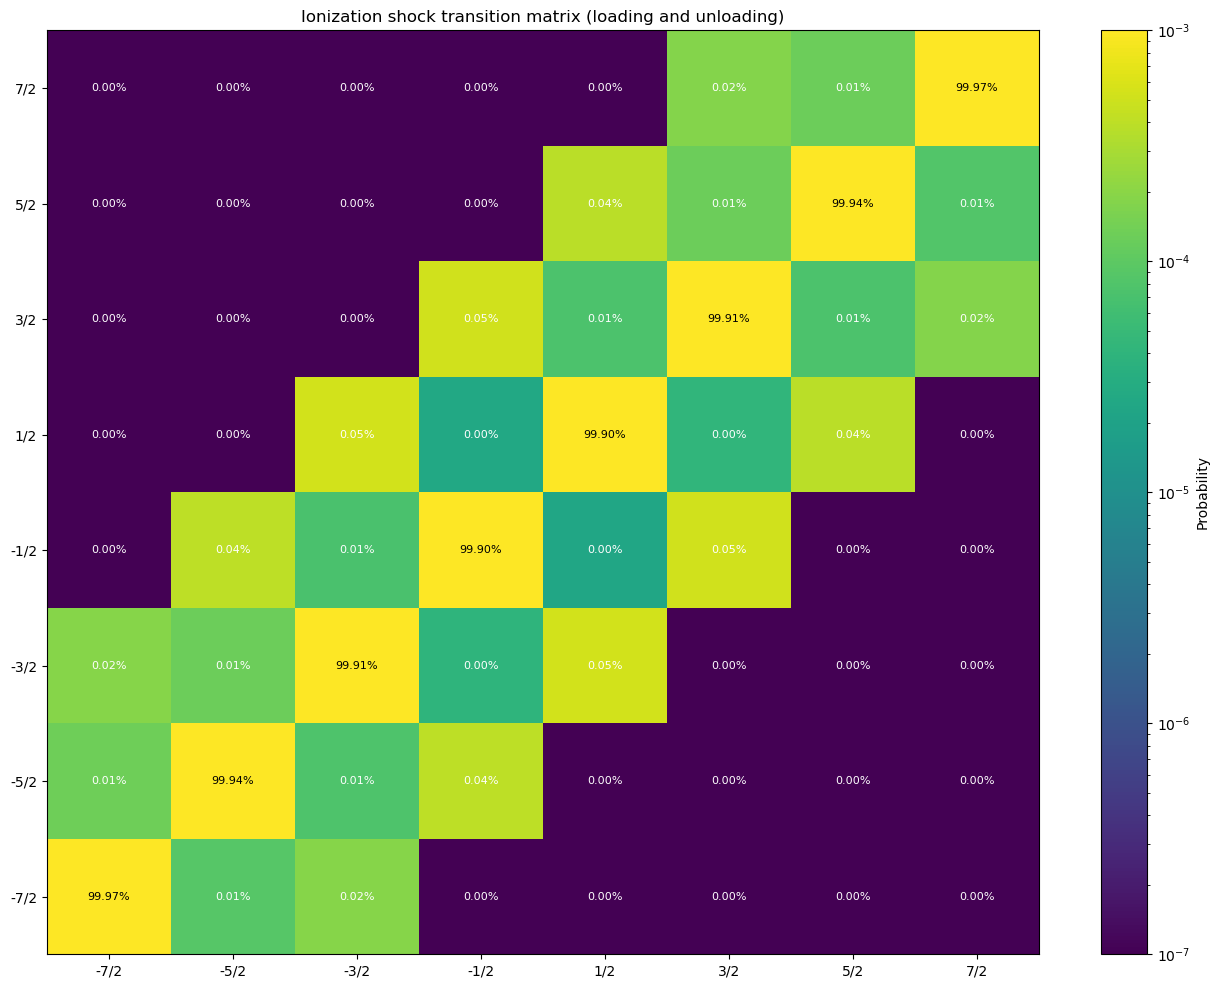

In [47]:
fig, ax = plt.subplots(1,1, figsize=(16,12))
Z = np.abs(ionization_matrix.T)
X, Y = np.arange(8), np.arange(8)
# Plot with pcolormesh using LogNorm
Z[Z==0]=1e-7

# Convert to percentage
Z_percent = Z * 100  
pcm = plt.pcolormesh(X, Y, Z, norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-3), cmap="viridis")

nucleus_labels = ["-7/2", "-5/2", "-3/2", "-1/2", "1/2", "3/2", "5/2", "7/2"]
electron_labels = [r"$\downarrow$", r"$\uparrow$", r"$^0$"]

ax.set_xticks(np.arange(8))
ax.set_yticks(np.arange(8))
ax.set_xticklabels([nucleus_labels[k%8] for k in range(8)])
ax.set_yticklabels([nucleus_labels[k%8] for k in range(8)])

# Annotate with percentages
for i in range(8):
    for j in range(8):
        color = 'black' if i == j else 'white'  # Diagonal elements in black
        ax.text(j, i, f"{Z_percent[i, j]:.2f}%", 
                ha='center', va='center', fontsize=8, color=color)

ax.set_title('Ionization shock transition matrix (loading and unloading)')

plt.colorbar(label='Probability')

In [48]:
# check normalization
np.sum(Z, axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1.])

In [49]:
from scipy.linalg import fractional_matrix_power
n_tunnel = 4.47
T_est = fractional_matrix_power(ionization_matrix, n_tunnel)

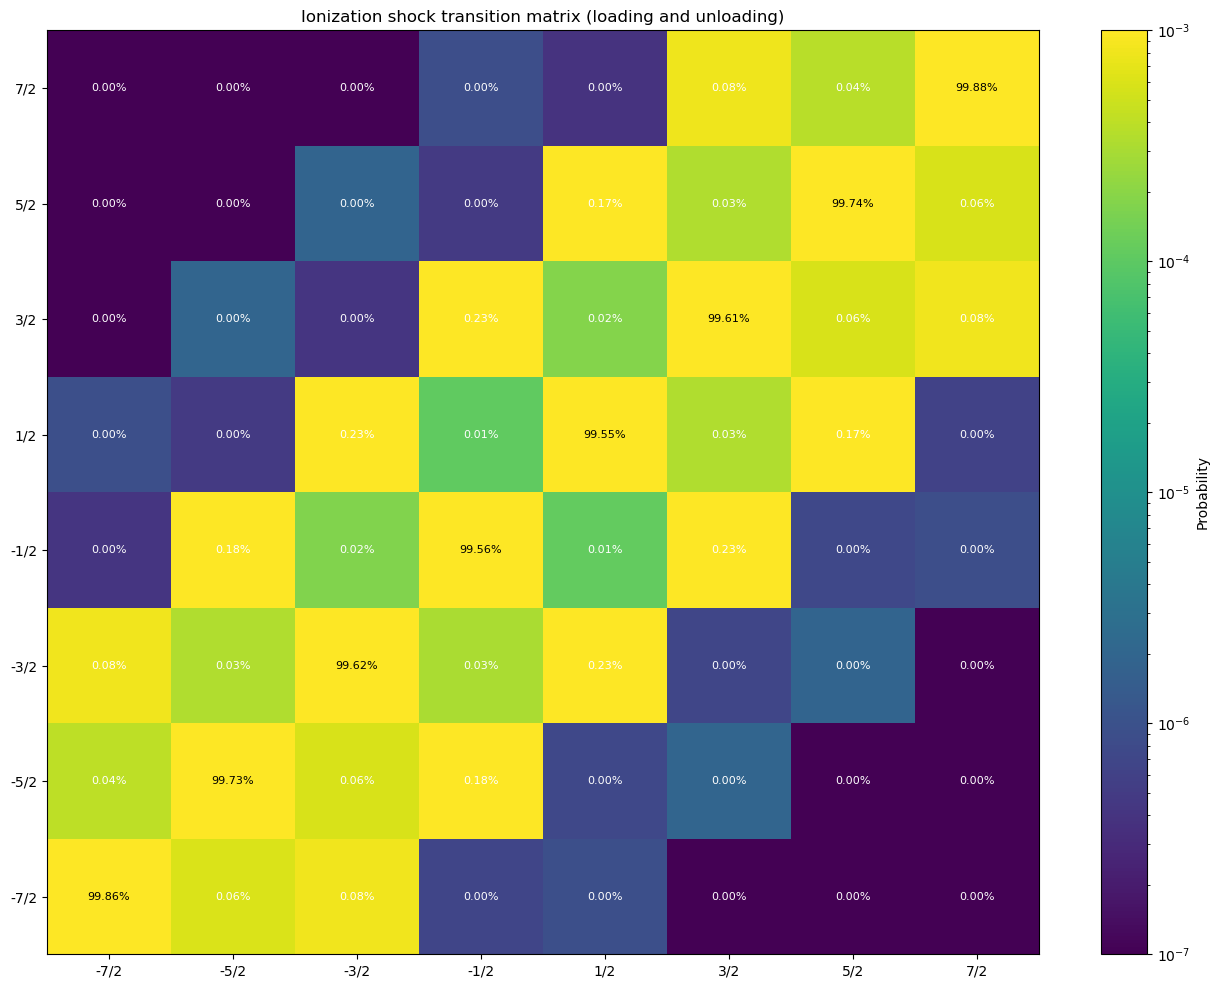

In [50]:
fig, ax = plt.subplots(1,1, figsize=(16,12))
Z = np.abs(T_est)
X, Y = np.arange(8), np.arange(8)
# Plot with pcolormesh using LogNorm
Z[Z==0]=1e-7

# Convert to percentage
Z_percent = Z * 100  
pcm = plt.pcolormesh(X, Y, Z, norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-3), cmap="viridis")

nucleus_labels = ["-7/2", "-5/2", "-3/2", "-1/2", "1/2", "3/2", "5/2", "7/2"]
electron_labels = [r"$\downarrow$", r"$\uparrow$", r"$^0$"]

ax.set_xticks(np.arange(8))
ax.set_yticks(np.arange(8))
ax.set_xticklabels([nucleus_labels[k%8] for k in range(8)])
ax.set_yticklabels([nucleus_labels[k%8] for k in range(8)])

# Annotate with percentages
for i in range(8):
    for j in range(8):
        color = 'black' if i == j else 'white'  # Diagonal elements in black
        ax.text(j, i, f"{Z_percent[i, j]:.2f}%", 
                ha='center', va='center', fontsize=8, color=color)

ax.set_title('Ionization shock transition matrix (loading and unloading)')

plt.colorbar(label='Probability')

In [242]:
np.save(r'sims_data/ionization_matrix.npy', ionization_matrix)